# TrustiPay Anomaly Risk Model (ML + xAI)

This notebook builds a business-focused anomaly risk model at transaction level with a cleaner evaluation workflow.

- **Target**: `is_high_risk` (synthetic label from transparent business rules)
- **Split strategy**: stratified train / validation / test split
- **Benchmarking**: dummy baseline vs tuned classifiers
- **Evaluation**: PR/ROC curves, threshold tuning on validation only, final holdout test metrics
- **xAI**: permutation importance + optional SHAP


## 1) Optional install

In [ ]:
# %pip install -q pandas numpy scikit-learn matplotlib seaborn joblib shap

In [1]:
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42


In [2]:
# Robust data path resolution
candidates = [
    Path('../synthetic_data/TrustiPay Synthetic Transactions.csv'),
    Path('synthetic_data/TrustiPay Synthetic Transactions.csv'),
    Path('../synthetic_data/synthetic_transactions_12000.csv'),
    Path('synthetic_data/synthetic_transactions_12000.csv'),
]

DATA_PATH = None
for candidate in candidates:
    if candidate.exists():
        DATA_PATH = candidate
        break

if DATA_PATH is None:
    raise FileNotFoundError('No synthetic CSV found in expected paths.')

df = pd.read_csv(DATA_PATH)
print(f'Loaded {len(df):,} rows from {DATA_PATH}')
df.head()

Loaded 12,000 rows from ../synthetic_data/TrustiPay Synthetic Transactions.csv


,external_tx_id,user_ref,occurred_at,amount,direction,category,description,currency
0,SYN-LARGE-00001,syn-user-0058,2025-01-13T13:08:47Z,11726.14,credit,Other Income,Other Income transaction,LKR
1,SYN-LARGE-00002,syn-user-0053,2025-12-13T19:02:01Z,10563.68,debit,Travel,Travel expense,LKR
2,SYN-LARGE-00003,syn-user-0048,2025-04-22T12:45:41Z,3627.78,debit,Debt,Debt expense,LKR
3,SYN-LARGE-00004,syn-user-0280,2025-08-03T06:48:51Z,14323.11,debit,Debt,Debt expense,LKR
4,SYN-LARGE-00005,syn-user-0082,2025-12-24T16:06:05Z,4096.17,debit,Healthcare,Healthcare expense,LKR


## 2) Feature engineering + risk target definition

In [3]:
df = df.copy()
df['occurred_at'] = pd.to_datetime(df['occurred_at'], utc=True, errors='coerce')
df['amount'] = pd.to_numeric(df['amount'], errors='coerce')
df = df.dropna(subset=['occurred_at', 'amount', 'direction'])

df['category'] = df['category'].fillna('Unknown')
df['currency'] = df['currency'].fillna('Unknown')
df['description'] = df['description'].fillna('Unknown')
df['user_ref'] = df['user_ref'].fillna('unknown-user')

df['hour'] = df['occurred_at'].dt.hour
df['day_of_week'] = df['occurred_at'].dt.dayofweek
df['month'] = df['occurred_at'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_night'] = ((df['hour'] <= 5) | (df['hour'] >= 22)).astype(int)

# User-level rolling behavior features
df = df.sort_values(['user_ref', 'occurred_at'])
df['user_tx_count_prev'] = df.groupby('user_ref').cumcount()
df['user_avg_amount_prev'] = (
    df.groupby('user_ref')['amount']
      .transform(lambda s: s.shift(1).expanding().mean())
      .fillna(df['amount'].median())
)
df['amount_to_user_avg_ratio'] = (df['amount'] / df['user_avg_amount_prev']).replace([np.inf, -np.inf], np.nan).fillna(1.0)

# Transparent synthetic risk rule (business-oriented)
risk_categories = {'Travel', 'Shopping', 'Entertainment', 'Debt'}
high_amount = df['amount'] >= df['amount'].quantile(0.92)
risky_category = df['category'].isin(risk_categories)
night_risk = df['is_night'] == 1
unusual_ratio = df['amount_to_user_avg_ratio'] >= 2.2

df['is_high_risk'] = (
    (high_amount & (risky_category | night_risk))
    | (unusual_ratio & (risky_category | night_risk))
).astype(int)

print('Risk label distribution:')
print(df['is_high_risk'].value_counts())
print('Risk ratio:', round(df['is_high_risk'].mean(), 4))

Risk label distribution:
is_high_risk
0    11578
1      422
Name: count, dtype: int64
Risk ratio: 0.0352


In [4]:
feature_cols = [
    'user_ref', 'category', 'currency',
    'amount', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_night',
    'user_tx_count_prev', 'user_avg_amount_prev', 'amount_to_user_avg_ratio'
]

X = df[feature_cols]
y = df['is_high_risk']

X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_dev,
)

split_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'rows': [len(X_train), len(X_val), len(X_test)],
    'share_of_total': [len(X_train) / len(X), len(X_val) / len(X), len(X_test) / len(X)],
    'positive_rate': [y_train.mean(), y_val.mean(), y_test.mean()],
}).round(4)

print('Split summary:')
display(split_summary)

categorical_features = ['user_ref', 'category', 'currency']
numeric_features = [
    'amount', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_night',
    'user_tx_count_prev', 'user_avg_amount_prev', 'amount_to_user_avg_ratio'
]

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numeric_features),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


## 3) Hyperparameter tuning

In [5]:
search_spaces = {
    'logistic_regression': {
        'pipeline': Pipeline([
            ('preprocess', preprocessor),
            ('clf', LogisticRegression(max_iter=4000, class_weight='balanced', random_state=RANDOM_STATE))
        ]),
        'params': {
            'clf__C': np.logspace(-3, 2, 24),
            'clf__solver': ['lbfgs', 'liblinear']
        }
    },
    'random_forest': {
        'pipeline': Pipeline([
            ('preprocess', preprocessor),
            ('clf', RandomForestClassifier(
                random_state=RANDOM_STATE,
                class_weight='balanced_subsample',
                n_jobs=-1
            ))
        ]),
        'params': {
            'clf__n_estimators': [200, 300, 500, 700],
            'clf__max_depth': [None, 10, 14, 18, 24],
            'clf__min_samples_split': [2, 5, 10],
            'clf__min_samples_leaf': [1, 2, 4],
            'clf__max_features': ['sqrt', 'log2', None]
        }
    }
}

results = []
best_search = None
best_model_name = None
best_val_pr_auc = -np.inf

baseline_model = DummyClassifier(strategy='prior')
baseline_model.fit(X_train, y_train)
baseline_proba = baseline_model.predict_proba(X_val)[:, 1]
baseline_pred = baseline_model.predict(X_val)

baseline_result = {
    'model': 'dummy_prior',
    'cv_best_average_precision': np.nan,
    'cv_std_average_precision': np.nan,
    'val_accuracy': accuracy_score(y_val, baseline_pred),
    'val_balanced_accuracy': balanced_accuracy_score(y_val, baseline_pred),
    'val_precision@0.5': precision_score(y_val, baseline_pred, zero_division=0),
    'val_recall@0.5': recall_score(y_val, baseline_pred, zero_division=0),
    'val_f1@0.5': f1_score(y_val, baseline_pred, zero_division=0),
    'val_pr_auc': average_precision_score(y_val, baseline_proba),
    'val_roc_auc': roc_auc_score(y_val, baseline_proba),
    'val_brier_score': brier_score_loss(y_val, baseline_proba),
    'best_params': {},
}
results.append(baseline_result)

for name, cfg in search_spaces.items():
    print(f'\nTuning {name}...')
    search = RandomizedSearchCV(
        estimator=cfg['pipeline'],
        param_distributions=cfg['params'],
        n_iter=18,
        scoring='average_precision',
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1,
        refit=True,
    )
    search.fit(X_train, y_train)

    val_proba = search.best_estimator_.predict_proba(X_val)[:, 1]
    val_pred = (val_proba >= 0.5).astype(int)

    pr_auc = average_precision_score(y_val, val_proba)
    result = {
        'model': name,
        'cv_best_average_precision': search.best_score_,
        'cv_std_average_precision': search.cv_results_['std_test_score'][search.best_index_],
        'val_accuracy': accuracy_score(y_val, val_pred),
        'val_balanced_accuracy': balanced_accuracy_score(y_val, val_pred),
        'val_precision@0.5': precision_score(y_val, val_pred, zero_division=0),
        'val_recall@0.5': recall_score(y_val, val_pred, zero_division=0),
        'val_f1@0.5': f1_score(y_val, val_pred, zero_division=0),
        'val_pr_auc': pr_auc,
        'val_roc_auc': roc_auc_score(y_val, val_proba),
        'val_brier_score': brier_score_loss(y_val, val_proba),
        'best_params': search.best_params_,
        'search_obj': search,
    }
    results.append(result)

    if pr_auc > best_val_pr_auc:
        best_val_pr_auc = pr_auc
        best_search = search
        best_model_name = name

results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'search_obj'} for r in results])
results_df = results_df.sort_values('val_pr_auc', ascending=False).reset_index(drop=True)
display(results_df)

if baseline_result['val_pr_auc'] >= best_val_pr_auc:
    print('Warning: the tuned models did not outperform the dummy baseline on validation PR AUC.')



Tuning logistic_regression...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Tuning random_forest...
Fitting 5 folds for each of 18 candidates, totalling 90 fits


/home/chanupa/anaconda3/envs/resersarch/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/chanupa/anaconda3/envs/resersarch/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/chanupa/anaconda3/envs/resersarch/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/chanupa/anaconda

,model,cv_best_average_precision,test_pr_auc,test_roc_auc,test_f1@0.5,best_params
0,random_forest,0.994052,0.998926,0.999959,0.962963,"{'clf__n_estimators': 500, 'clf__min_samples_s..."
1,logistic_regression,0.578978,0.554414,0.977938,0.524590,"{'clf__solver': 'liblinear', 'clf__C': 0.40615..."


## 4) Evaluation + threshold tuning

Best threshold by F1: 0.42

Classification report (best threshold):
              precision    recall  f1-score   support

           0     0.9991    0.9996    0.9994      2316
           1     0.9880    0.9762    0.9820        84

    accuracy                         0.9988      2400
   macro avg     0.9935    0.9879    0.9907      2400
weighted avg     0.9987    0.9988    0.9987      2400



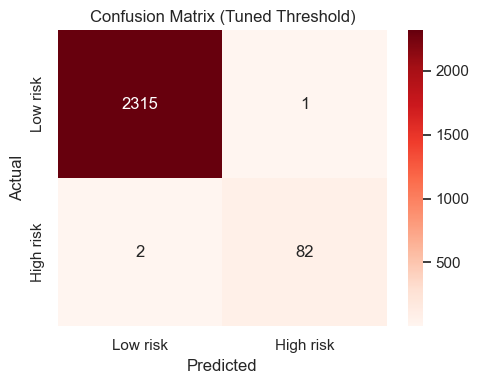

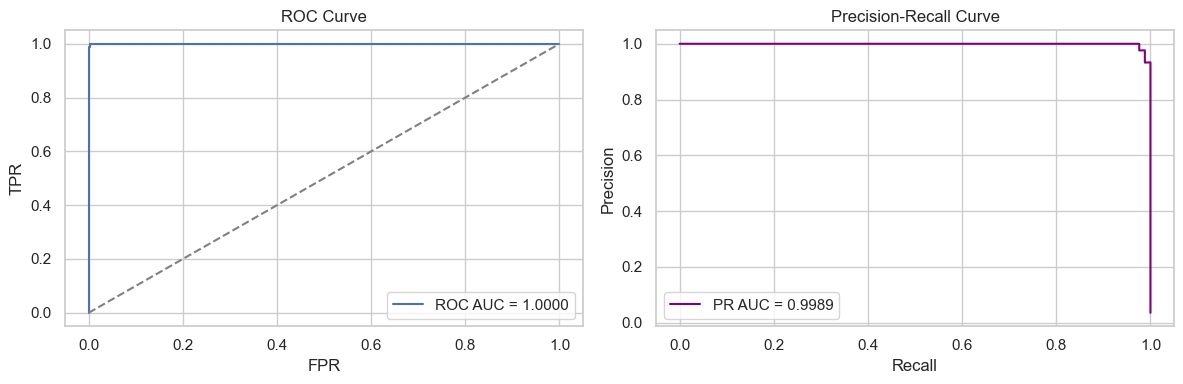

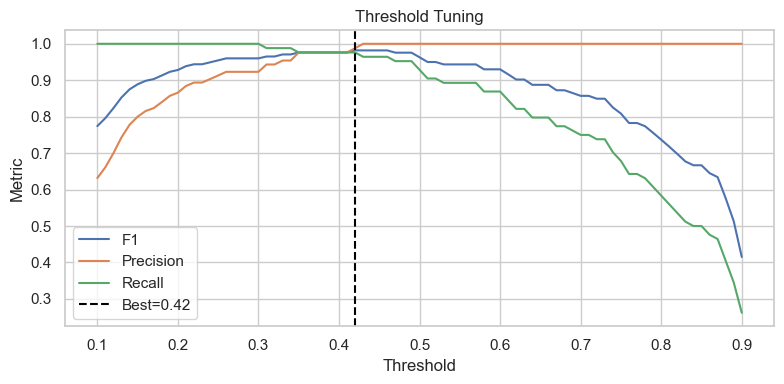

In [6]:
if best_search is None:
    raise RuntimeError('No tuned model was selected. Inspect the search results above.')

selected_model = best_search.best_estimator_
val_proba = selected_model.predict_proba(X_val)[:, 1]

# Tune threshold on validation only to avoid leaking information from the final test set.
def summarize_binary_metrics(y_true, y_score, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'pr_auc': average_precision_score(y_true, y_score),
        'roc_auc': roc_auc_score(y_true, y_score),
        'mcc': matthews_corrcoef(y_true, y_pred),
        'brier_score': brier_score_loss(y_true, y_score),
    }

thresholds = np.linspace(0.05, 0.95, 91)
threshold_metrics = []
for threshold in thresholds:
    val_pred = (val_proba >= threshold).astype(int)
    threshold_metrics.append({
        'threshold': threshold,
        'validation_accuracy': accuracy_score(y_val, val_pred),
        'validation_balanced_accuracy': balanced_accuracy_score(y_val, val_pred),
        'validation_precision': precision_score(y_val, val_pred, zero_division=0),
        'validation_recall': recall_score(y_val, val_pred, zero_division=0),
        'validation_f1': f1_score(y_val, val_pred, zero_division=0),
        'validation_mcc': matthews_corrcoef(y_val, val_pred),
    })

thr_df = pd.DataFrame(threshold_metrics)
best_thr = float(
    thr_df.sort_values(['validation_f1', 'validation_recall', 'validation_precision'], ascending=False).iloc[0]['threshold']
)

print(f'Selected model from validation: {best_model_name}')
print('Best model params:')
print(best_search.best_params_)
print(f'Best threshold by validation F1: {best_thr:.2f}')
display(thr_df.sort_values('validation_f1', ascending=False).head(10).reset_index(drop=True))

best_model = clone(selected_model)
best_model.fit(X_dev, y_dev)

test_proba = best_model.predict_proba(X_test)[:, 1]
pred_default = (test_proba >= 0.5).astype(int)
pred_tuned = (test_proba >= best_thr).astype(int)

test_metrics_df = pd.DataFrame([
    {'threshold': '0.50', **summarize_binary_metrics(y_test, test_proba, pred_default)},
    {'threshold': f'{best_thr:.2f}', **summarize_binary_metrics(y_test, test_proba, pred_tuned)},
]).round(4)

print('\nHoldout test metrics:')
display(test_metrics_df)
print('\nClassification report (tuned threshold):')
print(classification_report(y_test, pred_tuned, digits=4))

cm = confusion_matrix(y_test, pred_tuned)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Low risk', 'High risk'], yticklabels=['Low risk', 'High risk'])
plt.title('Confusion Matrix (Holdout Test Set, Tuned Threshold)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, test_proba)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(fpr, tpr, label=f'ROC AUC = {roc_auc_score(y_test, test_proba):.4f}')
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].legend()

axes[1].plot(recall_curve, precision_curve, label=f'PR AUC = {average_precision_score(y_test, test_proba):.4f}', color='teal')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(thr_df['threshold'], thr_df['validation_f1'], label='Validation F1')
plt.plot(thr_df['threshold'], thr_df['validation_precision'], label='Validation Precision')
plt.plot(thr_df['threshold'], thr_df['validation_recall'], label='Validation Recall')
plt.axvline(best_thr, linestyle='--', color='black', label=f'Best={best_thr:.2f}')
plt.title('Validation Threshold Tuning')
plt.xlabel('Threshold')
plt.ylabel('Metric')
plt.legend()
plt.tight_layout()
plt.show()


## 5) xAI

,feature,importance_mean,importance_std
1,category,0.614490,0.032768
11,amount_to_user_avg_ratio,0.473553,0.038811
3,amount,0.052977,0.004885
8,is_night,0.024163,0.002795
4,hour,0.011641,0.002176
10,user_avg_amount_prev,0.005611,0.001263
9,user_tx_count_prev,0.000549,0.000555
7,is_weekend,0.000136,0.000166
2,currency,0.000000,0.000000
6,month,-0.000005,0.000364


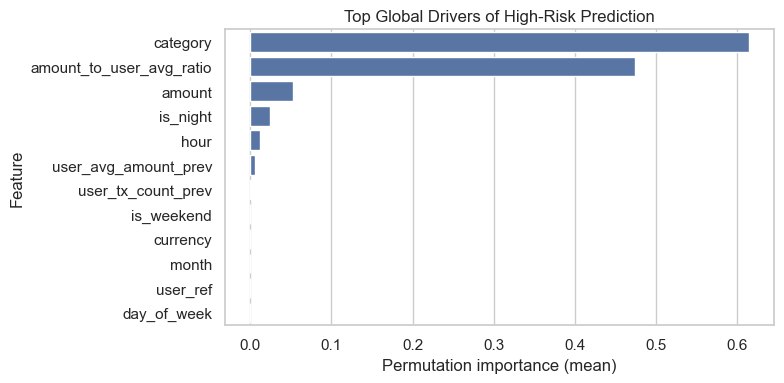

In [7]:
# xAI 1: Global feature impact using permutation importance
perm = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=8, random_state=42, n_jobs=-1,
    scoring='average_precision'
)

perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

display(perm_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=perm_df.head(12), y='feature', x='importance_mean', orient='h')
plt.title('Top Global Drivers of High-Risk Prediction')
plt.xlabel('Permutation importance (mean)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [8]:
# xAI 2: Optional SHAP summary for tree model
try:
    import shap

    clf = best_model.named_steps['clf']
    preprocess = best_model.named_steps['preprocess']

    if isinstance(clf, RandomForestClassifier):
        X_trans = preprocess.transform(X_test)
        sample_n = min(400, X_trans.shape[0])
        X_sample = X_trans[:sample_n]

        explainer = shap.TreeExplainer(clf)
        shap_values = explainer.shap_values(X_sample)
        feature_names = preprocess.get_feature_names_out()

        if isinstance(shap_values, list) and len(shap_values) > 1:
            shap.summary_plot(shap_values[1], X_sample, feature_names=feature_names, show=False)
        else:
            shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False)

        plt.title('SHAP Summary (High Risk class)')
        plt.tight_layout()
        plt.show()
    else:
        print('Best model is not tree-based; SHAP tree summary skipped.')
except Exception as exc:
    print(f'SHAP skipped (optional): {exc}')

SHAP skipped (optional): Cannot cast ufunc 'isnan' input from dtype('O') to dtype('bool') with casting rule 'same_kind'


In [9]:
# Save artifacts
model_path_candidates = [
    Path('../synthetic_data/trustipay_anomaly_risk_model.joblib'),
    Path('synthetic_data/trustipay_anomaly_risk_model.joblib')
]

save_path = model_path_candidates[0] if model_path_candidates[0].parent.exists() else model_path_candidates[1]
joblib.dump(best_model, save_path)
print(f'Saved model: {save_path}')

# Save threshold for deployment alignment
threshold_path = save_path.with_suffix('.threshold.txt')
threshold_path.write_text(str(best_thr), encoding='utf-8')
print(f'Saved threshold: {threshold_path}')

# Sample inference
sample = X_test.iloc[[0]].copy()
score = float(best_model.predict_proba(sample)[:, 1][0])
label = int(score >= best_thr)
display(sample)
print({'risk_score': round(score, 4), 'predicted_is_high_risk': label, 'threshold': round(best_thr, 4)})

Saved model: ../synthetic_data/trustipay_anomaly_risk_model.joblib
Saved threshold: ../synthetic_data/trustipay_anomaly_risk_model.threshold.txt


,user_ref,category,currency,amount,hour,day_of_week,month,is_weekend,is_night,user_tx_count_prev,user_avg_amount_prev,amount_to_user_avg_ratio
10444,syn-user-0075,Travel,LKR,10662.98,8,5,11,1,0,28,41005.616429,0.260037


{'risk_score': 0.0038, 'predicted_is_high_risk': 0, 'threshold': 0.42}
